In [1]:
import os
import sys
lib_path = os.path.abspath(os.path.join(os.path.abspath(''), 'functions/'))
sys.path.append(lib_path)
# need to append our functions dir to the path! 

import SD_raster_loading
import SD_NC_loading
import netCDF4
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dalecLoad
import spectralConv
import seaborn as sns
import scipy as sp
from datetime import timedelta
import matplotlib.dates as mdates

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.model_selection import GridSearchCV

In [8]:
coord = [56.146746528609306, -3.92285731543299] # this is perhaps a deeper part of the loch
S2_df = SD_NC_loading.load_multiple_SDs('S2_downloads/acolite_output/',
                                        coord, skipSameDay=False,
                                        pixel_grid_shape=(3,3),
                                        filetype="L2W.nc",
                                        variable='Rrs',
                                        div_by_pi=False,)

date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 f

In [9]:
SD_df = SD_NC_loading.load_multiple_SDs('planetData/acolite_output_L2W/',
                                         coord, skipSameDay=False, pixel_grid_shape=(10,10),
                                         filetype="L2W.nc",
                                         variable='Rrs',
                                         div_by_pi=False,)

date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 file!!!
date skipping doesnae work if we only have 1 f

In [10]:
S2_df = S2_df.reset_index()
S2_df['date'] = S2_df.Date.dt.date
SD_df = SD_df.reset_index()
SD_df['date'] = SD_df.Date.dt.date

In [12]:
SD_melt

,Date,date,Wavelength,location,Rrs
0,2022-04-19 10:47:11+00:00,2022-04-19,444.0,rho_s_58_89,0.0043351226
1,2022-04-19 10:47:11+00:00,2022-04-19,492.0,rho_s_58_89,0.0049421196
2,2022-04-19 10:47:11+00:00,2022-04-19,533.0,rho_s_58_89,0.0056924177
3,2022-04-19 10:47:11+00:00,2022-04-19,566.0,rho_s_58_89,0.00782855
4,2022-04-19 10:47:11+00:00,2022-04-19,612.0,rho_s_58_89,0.006636364
...,...,...,...,...,...
87995,2023-10-11 10:31:23+00:00,2023-10-11,566.0,rho_s_67_98,0.007557674
87996,2023-10-11 10:31:23+00:00,2023-10-11,612.0,rho_s_67_98,0.0076947724
87997,2023-10-11 10:31:23+00:00,2023-10-11,666.0,rho_s_67_98,0.006110564
87998,2023-10-11 10:31:23+00:00,2023-10-11,707.0,rho_s_67_98,0.008118072


# Load only clean data
Interestingly, this doesn't really affect the results. If anything, including data with haze, shadows etc. improves the fit of regression graphs as we get more data points!

Might be an idea to do a slightly more loose cleaning of the planet images - maybe shadows are fine?
Or I could include a flag column in the data and see if any particular types of error are causing issues?

- I think the blues will be most badly affected by haze, but we're not using these anyway
- I think shadow might not be such a big issue
- I'm not sure why some images appear blurry, but maybe these also aren't an issue...

## what about S2?

- well I think probably best to just work on the assumption that the S2 masking is pretty good, and so any bad S2 images will be full of NAs anyhoo

In [20]:
# load list of good files from data review csv...
good_df = pd.read_csv('planetData/good_data_review.csv')
extra_good = good_df.copy()
# select everything except images with cloud cover
extra_good = good_df.copy()[good_df['flag'] != 'cloud']
# uncomment this line for selection of only 'good' images
#extra_good = good_df.copy()[good_df['atmospheric interference at measurement points'] == 'good']

good_files = []
for f in extra_good.filename:
    #good_files.append(f[1:5] + '_' + f[5:7] + '_' + f[7:9] + '_' + f[10:12]+ '_' + f[12:14]+ '_' + f[14:16])
    good_files.append(f[1:16])

good_dates = pd.to_datetime(good_files, format='%Y%m%d_%H%M%S', utc=True)
# remove bad dates
SD_df = SD_df[SD_df.Date.isin(good_dates)]

In [22]:
S2_melt = pd.melt(S2_df, id_vars=['Date', 'date', 'Wavelength'],
                   var_name='location', value_name='Rrs')
SD_melt = pd.melt(SD_df, id_vars=['Date', 'date', 'Wavelength'],
                   var_name='location', value_name='Rrs')

In [23]:
SD_melt

,Date,date,Wavelength,location,Rrs
0,2022-04-19 10:47:11+00:00,2022-04-19,444.0,rho_s_58_89,0.0043351226
1,2022-04-19 10:47:11+00:00,2022-04-19,492.0,rho_s_58_89,0.0049421196
2,2022-04-19 10:47:11+00:00,2022-04-19,533.0,rho_s_58_89,0.0056924177
3,2022-04-19 10:47:11+00:00,2022-04-19,566.0,rho_s_58_89,0.00782855
4,2022-04-19 10:47:11+00:00,2022-04-19,612.0,rho_s_58_89,0.006636364
...,...,...,...,...,...
85595,2023-10-11 10:31:23+00:00,2023-10-11,566.0,rho_s_67_98,0.007557674
85596,2023-10-11 10:31:23+00:00,2023-10-11,612.0,rho_s_67_98,0.0076947724
85597,2023-10-11 10:31:23+00:00,2023-10-11,666.0,rho_s_67_98,0.006110564
85598,2023-10-11 10:31:23+00:00,2023-10-11,707.0,rho_s_67_98,0.008118072


In [203]:
S2_med = S2_melt.drop(['location'], axis=1).groupby(['Date', 'date', 'Wavelength']).median()
S2_med.rename(columns={'Rrs':'Rrs_S2'}, inplace=True)
S2_med = S2_med.dropna().reset_index()

SD_med = SD_melt.drop(['location'], axis=1).groupby(['Date', 'date', 'Wavelength']).median()
SD_med.rename(columns={'Rrs':'Rrs_SD'}, inplace=True)
SD_med = SD_med.reset_index()

In [204]:
S2_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   Date        583 non-null    datetime64[ns, UTC]
 1   date        583 non-null    object             
 2   Wavelength  583 non-null    float64            
 3   Rrs_S2      583 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 18.3+ KB


In [205]:
SD_med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   Date        856 non-null    datetime64[ns, UTC]
 1   date        856 non-null    object             
 2   Wavelength  856 non-null    float64            
 3   Rrs_SD      856 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 26.9+ KB


In [206]:
dalec_S2A = pd.read_csv('DALEC_S2A_bands_2022_23.csv')
dalec_S2A.drop(['Unnamed: 0', 'month', 'year', 'Date'], axis=1, inplace=True)
dalec_S2A.rename(columns={'Rrs':'Rrs_DALEC', 'wavelength':'Wavelength'}, inplace=True)
dalec_S2A = dalec_S2A.groupby(['Wavelength', 'date']).median().reset_index()
dalec_S2A

,Wavelength,date,Rrs_DALEC
0,443.0,2022-07-28,0.003411
1,443.0,2022-07-31,0.003916
2,443.0,2022-08-01,0.003722
3,443.0,2022-08-02,0.003529
4,443.0,2022-08-03,0.002912
...,...,...,...
1243,2202.0,2023-09-26,NaN
1244,2202.0,2023-09-27,NaN
1245,2202.0,2023-09-28,NaN
1246,2202.0,2023-09-29,NaN


In [207]:
dalec_S2B = pd.read_csv('DALEC_S2B_bands_2022_23.csv')
dalec_S2B.drop(['Unnamed: 0', 'month', 'year', 'Date'], axis=1, inplace=True)
dalec_S2B.rename(columns={'Rrs':'Rrs_DALEC', 'wavelength':'Wavelength'}, inplace=True)
dalec_S2B = dalec_S2B.groupby(['Wavelength', 'date']).median().reset_index()
dalec_S2B

,Wavelength,date,Rrs_DALEC
0,442.0,2022-07-28,0.003404
1,442.0,2022-07-31,0.003909
2,442.0,2022-08-01,0.003717
3,442.0,2022-08-02,0.003525
4,442.0,2022-08-03,0.002907
...,...,...,...
1243,2186.0,2023-09-26,NaN
1244,2186.0,2023-09-27,NaN
1245,2186.0,2023-09-28,NaN
1246,2186.0,2023-09-29,NaN


In [208]:
dalec_SD = pd.read_csv('DALEC_SD_bands_2022_23.csv')
dalec_SD.drop(['Unnamed: 0', 'month', 'year', 'Date'], axis=1, inplace=True)
dalec_SD.rename(columns={'Rrs':'Rrs_DALEC', 'wavelength':'Wavelength'}, inplace=True)
dalec_SD = dalec_SD.groupby(['Wavelength', 'date']).median().reset_index()
dalec_SD

,Wavelength,date,Rrs_DALEC
0,444.0,2022-07-28,0.003432
1,444.0,2022-07-31,0.003935
2,444.0,2022-08-01,0.003738
3,444.0,2022-08-02,0.003542
4,444.0,2022-08-03,0.002927
...,...,...,...
763,866.0,2023-09-26,0.003964
764,866.0,2023-09-27,0.003757
765,866.0,2023-09-28,0.002344
766,866.0,2023-09-29,0.001369


In [209]:
S2_med.date = pd.to_datetime(S2_med.date)
S2_med['original_date'] = 'nan'
S2_med['date_flag'] = 0

In [210]:
S2_med.loc[S2_med.date=='2022-07-29', 'original_date'] = '2022-07-29'
S2_med.loc[S2_med.date=='2023-09-02', 'original_date'] = '2023-09-02'
S2_med.loc[S2_med.date=='2023-09-04', 'original_date'] = '2023-09-04'

S2_med.loc[S2_med.date=='2022-07-29', 'date_flag'] = 1
S2_med.loc[S2_med.date=='2023-09-02', 'date_flag'] = 1
S2_med.loc[S2_med.date=='2023-09-04', 'date_flag'] = 1

S2_med.loc[S2_med.date=='2022-07-29', 'date'] = pd.to_datetime('2022-07-28')
S2_med.loc[S2_med.date=='2023-09-02', 'date'] = pd.to_datetime('2023-09-01')
S2_med.loc[S2_med.date=='2023-09-04', 'date'] = pd.to_datetime('2023-09-06')

In [213]:
dalec_S2A['date'] = pd.to_datetime(dalec_S2A.date)
dalec_s2a = dalec_S2A.merge(S2_med, on=['date', 'Wavelength'], how='left').dropna()


In [214]:
dalec_s2a

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2,original_date,date_flag
10,443.0,2022-08-10,0.004042,2022-08-10 11:35:51.356894+00:00,0.000393,nan,0.0
17,443.0,2023-07-09,0.000226,2023-07-09 11:45:41.249512+00:00,0.00893,nan,0.0
24,443.0,2023-07-16,0.001330,2023-07-16 11:35:44.169426+00:00,0.071764,nan,0.0
27,443.0,2023-07-19,0.000320,2023-07-19 11:45:40.094481+00:00,0.014316,nan,0.0
37,443.0,2023-07-29,0.000241,2023-07-29 11:45:41.220752+00:00,0.016261,nan,0.0
...,...,...,...,...,...,...,...
805,865.0,2023-07-29,0.007271,2023-07-29 11:45:41.220752+00:00,0.024247,nan,0.0
815,865.0,2023-08-08,0.001983,2023-08-08 11:45:40.340448+00:00,0.010505,nan,0.0
834,865.0,2023-08-28,0.002710,2023-08-28 11:45:41.668952+00:00,0.073871,nan,0.0
839,865.0,2023-09-06,0.002989,2023-09-04 11:35:44.833521+00:00,0.008627,2023-09-04,1.0


In [215]:
S2_med.date_flag.unique()

array([0, 1])

In [216]:
dalec_S2B['date'] = pd.to_datetime(dalec_S2B.date)
S2_med['date'] = pd.to_datetime(S2_med.date)
dalec_s2b = dalec_S2B.merge(S2_med, on=['date', 'Wavelength'], how='left').dropna()


In [217]:
dalec_s2b

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2,original_date,date_flag
0,442.0,2022-07-28,0.003404,2022-07-29 11:45:40.942094+00:00,0.001898,2022-07-29,1.0
70,442.0,2023-09-01,0.000871,2023-09-02 11:45:40.778585+00:00,0.003524,2023-09-02,1.0
77,442.0,2023-09-12,0.000529,2023-09-12 11:45:39.402233+00:00,0.016816,nan,0.0
94,442.0,2023-09-29,0.000183,2023-09-29 11:35:41.859230+00:00,0.003478,nan,0.0
96,492.0,2022-07-28,0.004902,2022-07-29 11:45:40.942094+00:00,0.001389,2022-07-29,1.0
...,...,...,...,...,...,...,...
766,833.0,2023-09-29,0.001472,2023-09-29 11:35:41.859230+00:00,0.013529,nan,0.0
768,864.0,2022-07-28,0.001674,2022-07-29 11:45:40.942094+00:00,0.007594,2022-07-29,1.0
838,864.0,2023-09-01,0.002082,2023-09-02 11:45:40.778585+00:00,0.009428,2023-09-02,1.0
845,864.0,2023-09-12,0.000955,2023-09-12 11:45:39.402233+00:00,0.03041,nan,0.0


In [218]:
# bit hacky, but we identify which images are S2A vs S2B by looking at the first band
# and checking if it is 442 or 443
S2B_dates = dalec_s2b[dalec_s2b.Wavelength==442].date
S2A_dates = dalec_s2a[dalec_s2a.Wavelength==443].date

In [219]:
dalec_s2a = dalec_s2a[dalec_s2a.date.isin(S2A_dates)]
dalec_s2a

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2,original_date,date_flag
10,443.0,2022-08-10,0.004042,2022-08-10 11:35:51.356894+00:00,0.000393,nan,0.0
17,443.0,2023-07-09,0.000226,2023-07-09 11:45:41.249512+00:00,0.00893,nan,0.0
24,443.0,2023-07-16,0.001330,2023-07-16 11:35:44.169426+00:00,0.071764,nan,0.0
27,443.0,2023-07-19,0.000320,2023-07-19 11:45:40.094481+00:00,0.014316,nan,0.0
37,443.0,2023-07-29,0.000241,2023-07-29 11:45:41.220752+00:00,0.016261,nan,0.0
...,...,...,...,...,...,...,...
805,865.0,2023-07-29,0.007271,2023-07-29 11:45:41.220752+00:00,0.024247,nan,0.0
815,865.0,2023-08-08,0.001983,2023-08-08 11:45:40.340448+00:00,0.010505,nan,0.0
834,865.0,2023-08-28,0.002710,2023-08-28 11:45:41.668952+00:00,0.073871,nan,0.0
839,865.0,2023-09-06,0.002989,2023-09-04 11:35:44.833521+00:00,0.008627,2023-09-04,1.0


In [220]:
dalec_s2b = dalec_s2b[dalec_s2b.date.isin(S2B_dates)]
dalec_S2 = pd.concat([dalec_s2b, dalec_s2a], ignore_index=True)

In [221]:
dalec_S2

,Wavelength,date,Rrs_DALEC,Date,Rrs_S2,original_date,date_flag
0,442.0,2022-07-28,0.003404,2022-07-29 11:45:40.942094+00:00,0.001898,2022-07-29,1.0
1,442.0,2023-09-01,0.000871,2023-09-02 11:45:40.778585+00:00,0.003524,2023-09-02,1.0
2,442.0,2023-09-12,0.000529,2023-09-12 11:45:39.402233+00:00,0.016816,nan,0.0
3,442.0,2023-09-29,0.000183,2023-09-29 11:35:41.859230+00:00,0.003478,nan,0.0
4,492.0,2022-07-28,0.004902,2022-07-29 11:45:40.942094+00:00,0.001389,2022-07-29,1.0
...,...,...,...,...,...,...,...
112,865.0,2023-07-29,0.007271,2023-07-29 11:45:41.220752+00:00,0.024247,nan,0.0
113,865.0,2023-08-08,0.001983,2023-08-08 11:45:40.340448+00:00,0.010505,nan,0.0
114,865.0,2023-08-28,0.002710,2023-08-28 11:45:41.668952+00:00,0.073871,nan,0.0
115,865.0,2023-09-06,0.002989,2023-09-04 11:35:44.833521+00:00,0.008627,2023-09-04,1.0


In [229]:
def nearest_wavelength(w_in, w_list):
    diff = np.abs(w_list - w_in)
    return w_list[np.argmin(diff)]

In [231]:
# set s2a and s2b wavelengths to be the same
dalec_S2['Wavelength'] = dalec_S2.Wavelength.apply(nearest_wavelength,
                                                   args=[dalec_s2a.Wavelength.unique()])

In [222]:
SD_med.date = pd.to_datetime(SD_med.date)
SD_med['original_date'] = 'nan'
SD_med['date_flag'] = 0

SD_med.loc[SD_med.date=='2023-10-01', 'original_date'] = '2023-10-01'
SD_med.loc[SD_med.date=='2022-08-17', 'original_date'] = '2022-08-17'
SD_med.loc[SD_med.date=='2023-09-03', 'original_date'] = '2023-09-03'

SD_med.loc[SD_med.date=='2023-10-01', 'date_flag'] = 1
SD_med.loc[SD_med.date=='2022-08-17', 'date_flag'] = 1
SD_med.loc[SD_med.date=='2023-09-03', 'date_flag'] = 1

SD_med.loc[SD_med.date=='2023-10-01', 'date'] = pd.to_datetime('2023-09-30')
SD_med.loc[SD_med.date=='2022-08-17', 'date'] = pd.to_datetime('2022-08-15')
SD_med.loc[SD_med.date=='2023-09-03', 'date'] = pd.to_datetime('2023-09-01')

In [223]:
dalec_SD['date'] = pd.to_datetime(dalec_SD.date)
SD_med['date'] = pd.to_datetime(SD_med.date)
dalec_sd = dalec_SD.merge(SD_med, on=['date', 'Wavelength'], how='left').dropna()
dalec_sd

,Wavelength,date,Rrs_DALEC,Date,Rrs_SD,original_date,date_flag
10,444.0,2022-08-10,0.004061,2022-08-10 10:27:06+00:00,0.003781,nan,0.0
11,444.0,2022-08-11,0.003798,2022-08-11 10:28:21+00:00,0.003351,nan,0.0
12,444.0,2022-08-11,0.003798,2022-08-11 10:28:23+00:00,0.003487,nan,0.0
14,444.0,2022-08-13,0.003795,2022-08-13 11:13:41+00:00,0.004353,nan,0.0
16,444.0,2022-08-15,0.003999,2022-08-17 11:03:56+00:00,0.004671,2022-08-17,1.0
...,...,...,...,...,...,...,...
848,866.0,2023-09-08,0.002888,2023-09-08 11:10:08+00:00,0.028139,nan,0.0
851,866.0,2023-09-11,0.001588,2023-09-11 10:30:46+00:00,0.030034,nan,0.0
852,866.0,2023-09-12,0.000951,2023-09-12 10:32:01+00:00,0.014361,nan,0.0
853,866.0,2023-09-12,0.000951,2023-09-12 11:11:16+00:00,0.013276,nan,0.0


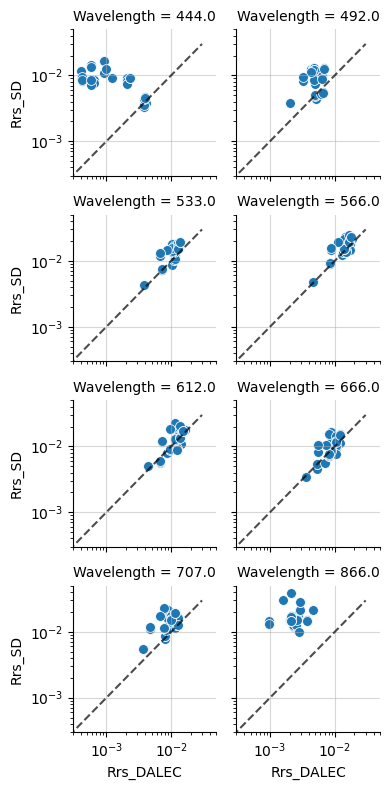

In [277]:
g = sns.FacetGrid(dalec_sd,#[dalec_sd.year == 2023],
                  col='Wavelength', col_wrap=2, height=2,
                  #sharex=False, sharey=False
                 )


g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='Rrs_SD',
                #style='Sat_ID',
                #hue='year',
                legend=True,
                #style='date',
                s=50)

for ax in g.axes.flat[:]:
    ax.plot([0, 0.03], [0, 0.03], 'k--', alpha=0.7)
    ax.set_xlim(.3e-3, 0.05)
    ax.set_ylim(.3e-3, 0.05)
    ax.grid(alpha=0.5)

g.set(xscale="log")
g.set(yscale="log")


plt.tight_layout()
#plt.gca().legend()

plt.show()




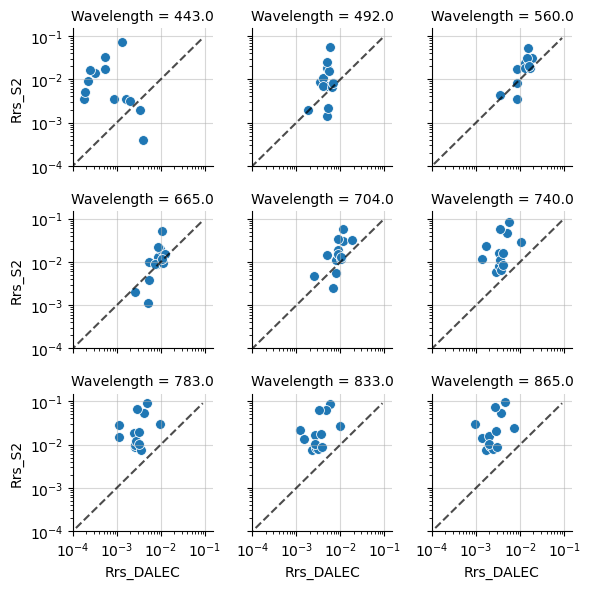

In [276]:
g = sns.FacetGrid(dalec_S2,#[dalec_sd.year == 2023],
                  col='Wavelength', col_wrap=3, height=2)

g.map_dataframe(sns.scatterplot, x='Rrs_DALEC', y='Rrs_S2',
                #style='Sat_ID',
                #hue='year',
                legend=True,
                #style='date',
                s=50)

for ax in g.axes.flat:
    ax.plot([0, 0.09], [0, 0.09], 'k--', alpha=0.7)
    ax.set_xlim(1e-4, 0.15)
    ax.set_ylim(1e-4, 0.15)
    ax.grid(alpha=0.5)
    
g.set(xscale="log")
g.set(yscale="log")

plt.tight_layout()
#plt.gca().legend()

plt.show()




In [329]:
def chla_NIR_rat(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    just use NIR ratio 708/666 with no coefficients
    '''
    ratio = df[Rrs_708] / df[Rrs_666]
    return ratio

def chla_NDCI(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    use NCDI NIR ratio (708-666)/(708+666)
    '''
    ratio = (df[Rrs_708] - df[Rrs_666]) / (df[Rrs_708] + df[Rrs_666])
    return ratio

def chla_OC4(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)'''
    X = np.log10(np.array(np.max([df[Rrs_444], df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))

def chla_OC4_mod(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)
    with Rrs_444 removed as we cant trust this one... '''
    X = np.log10(np.array(np.max([df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_OC3(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2424, b=-2.2146,
             c=1.5193, d=-0.7702,
             e=-0.4291, returnX=False):
    '''3 band NASA alg (model M in claire neil paper)'''
    X = np.log10(np.array(np.max([df[Rrs_444],
                                  df[Rrs_492]],
                                 axis=0)/(df[Rrs_566]), dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
                
def chla_OC2(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2389, b=-1.9369,
             c=1.7627, d=-3.0777,
             e=-0.1054, returnX=False):
    '''2 band NASA alg (model N in claire neil paper)'''
    X = np.log10(np.array(df[Rrs_492]/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_RBD(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    NIR/red band difference
    '''
    return df[Rrs_708] - df[Rrs_666]

def chla_RBR3(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666', Rrs_866='Rrs_866'):
    return (df[Rrs_666]**-1 - df[Rrs_708]**-1) * df[Rrs_866]



In [330]:
S2_med.Wavelength.unique()

array([ 442.,  492.,  559.,  665.,  704.,  739.,  780.,  833.,  864.,
       1610., 2186.,  443.,  560.,  740.,  783.,  865., 1614., 2202.])

In [331]:
SD_med

,Date,date,Wavelength,Rrs_SD,original_date,date_flag
0,2022-04-19 10:47:11+00:00,2022-04-19,444.0,0.006726,nan,0
1,2022-04-19 10:47:11+00:00,2022-04-19,492.0,0.004648,nan,0
2,2022-04-19 10:47:11+00:00,2022-04-19,533.0,0.005316,nan,0
3,2022-04-19 10:47:11+00:00,2022-04-19,566.0,0.007651,nan,0
4,2022-04-19 10:47:11+00:00,2022-04-19,612.0,0.006986,nan,0
...,...,...,...,...,...,...
851,2023-10-11 10:31:23+00:00,2023-10-11,566.0,0.007605,nan,0
852,2023-10-11 10:31:23+00:00,2023-10-11,612.0,0.006685,nan,0
853,2023-10-11 10:31:23+00:00,2023-10-11,666.0,0.005901,nan,0
854,2023-10-11 10:31:23+00:00,2023-10-11,707.0,0.008256,nan,0


In [332]:
S2_med_ab = S2_med.copy()[S2_med.Wavelength<866]
# set s2a and s2b wavelengths to be the same
S2_med_ab['Wavelength'] = S2_med_ab.Wavelength.apply(nearest_wavelength,
                                                   args=[dalec_s2a.Wavelength.unique()])

s2_dict = {'Date':S2_med_ab[S2_med_ab.Wavelength==443.0].reset_index().Date,
           'date':S2_med_ab[S2_med_ab.Wavelength==443.0].reset_index().date}
sd_dict = {'Date':SD_med[SD_med.Wavelength==444.0].reset_index().Date,
           'date':SD_med[SD_med.Wavelength==444.0].reset_index().date}
dalec_dict = {'date':dalec_S2A[dalec_S2A.Wavelength==443.0].reset_index().date}

for wavelength in S2_med_ab.Wavelength.unique():
    s2_dict['Rrs_'+str(int(wavelength))] = S2_med_ab[S2_med_ab.Wavelength==wavelength].reset_index().Rrs_S2
    dalec_dict['Rrs_'+str(int(wavelength))] = dalec_S2A[dalec_S2A.Wavelength==wavelength].reset_index().Rrs_DALEC

for wavelength in SD_med.Wavelength.unique():
    sd_dict['Rrs_'+str(int(wavelength))] = SD_med[SD_med.Wavelength==wavelength].reset_index().Rrs_SD

    
s2_chla = pd.DataFrame(data=s2_dict)
sd_chla = pd.DataFrame(data=sd_dict)
dalec_chla = pd.DataFrame(data=dalec_dict)

In [333]:
s2_chla

,Date,date,Rrs_443,Rrs_492,Rrs_560,Rrs_665,Rrs_704,Rrs_740,Rrs_783,Rrs_833,Rrs_865
0,2022-03-01 11:45:32.611188+00:00,2022-03-01,0.001242,0.00097,0.001958,0.000674,0.00216,0.003098,0.003409,0.003495,0.003084
1,2022-03-06 11:45:39.885309+00:00,2022-03-06,0.00048,0.001567,0.002661,0.001026,0.00261,0.003122,0.003746,0.003539,0.003685
2,2022-03-08 11:35:37.194248+00:00,2022-03-08,0.002573,0.00213,0.002895,0.000942,0.002373,0.004419,0.004332,0.004079,0.003957
3,2022-03-21 11:45:33.892844+00:00,2022-03-21,0.000196,0.000829,0.002363,0.000633,0.002497,0.004164,0.004746,0.004677,0.004336
4,2022-03-23 11:35:42.407324+00:00,2022-03-23,0.000049,0.000838,0.003877,0.002079,0.005489,0.012031,0.013519,0.01268,0.013082
5,2022-03-26 11:45:38.643025+00:00,2022-03-26,0.001646,0.000804,0.003069,0.000948,0.005295,0.011781,0.013358,0.0108,0.013372
6,2022-03-28 11:35:36.500382+00:00,2022-03-28,0.000694,0.001067,0.002862,0.000708,0.002846,0.005773,0.007109,0.006446,0.005882
7,2022-04-20 11:45:31.202597+00:00,2022-04-20,0.000321,0.001297,0.004211,0.001567,0.003415,0.005881,0.00646,0.00596,0.005403
8,2022-04-22 11:35:44.118029+00:00,2022-04-22,0.001975,0.001986,0.005481,0.002098,0.003916,0.005756,0.00689,0.006949,0.006889
9,2022-05-25 11:45:43.216253+00:00,2022-05-25,0.01368,0.016416,0.017576,0.008973,0.013528,0.015678,0.018537,0.033264,0.017881


In [334]:
# sentinel 2

s2_chla['NIR'] = chla_NIR_rat(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['NDCI'] = chla_NDCI(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['RBD'] = chla_RBD(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['RBR3'] = chla_RBR3(s2_chla, Rrs_708='Rrs_704',
                            Rrs_666='Rrs_665', Rrs_866='Rrs_865')


s2_chla['OC3_X'] = chla_OC3(s2_chla, returnX=True,
                            Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                            Rrs_566='Rrs_560',)
s2_chla['OC2_X'] = chla_OC2(s2_chla, returnX=True,
                            Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                            Rrs_566='Rrs_560',)


s2_chla['OC3'] = chla_OC3(s2_chla,
                          Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                          Rrs_566='Rrs_560',)
s2_chla['OC2'] = chla_OC2(s2_chla,
                          Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                          Rrs_566='Rrs_560',)

# dalec

dalec_chla['NIR'] = chla_NIR_rat(dalec_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
dalec_chla['NDCI'] = chla_NDCI(dalec_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
dalec_chla['RBD'] = chla_RBD(dalec_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
dalec_chla['RBR3'] = chla_RBR3(dalec_chla, Rrs_708='Rrs_704',
                               Rrs_666='Rrs_665', Rrs_866='Rrs_865')

dalec_chla['OC3_X'] = chla_OC3(dalec_chla, returnX=True,
                               Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                               Rrs_566='Rrs_560',)
dalec_chla['OC2_X'] = chla_OC2(dalec_chla, returnX=True, 
                               Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                               Rrs_566='Rrs_560',)

dalec_chla['OC3'] = chla_OC3(dalec_chla, Rrs_444='Rrs_443',
                             Rrs_492='Rrs_492',
                             Rrs_566='Rrs_560',)
dalec_chla['OC2'] = chla_OC2(dalec_chla, Rrs_444='Rrs_443',
                             Rrs_492='Rrs_492',
                             Rrs_566='Rrs_560',)


In [336]:
sd_chla['NIR'] = chla_NIR_rat(sd_chla)
sd_chla['NDCI'] = chla_NDCI(sd_chla)
sd_chla['OC4_X'] = chla_OC4(sd_chla, returnX=True)
sd_chla['OC4_mod_X'] = chla_OC4_mod(sd_chla, returnX=True)

sd_chla['OC3_X'] = chla_OC3(sd_chla, returnX=True)
sd_chla['OC2_X'] = chla_OC2(sd_chla, returnX=True)

sd_chla['OC4'] = chla_OC4(sd_chla)
sd_chla['OC3'] = chla_OC3(sd_chla)
sd_chla['OC2'] = chla_OC2(sd_chla)

sd_chla['RBD'] = chla_RBD(sd_chla)
sd_chla['RBR3'] = chla_RBR3(sd_chla)

In [338]:
insitu_chl = pd.read_csv('data/chl-a/airthrey_chl.csv')
insitu_chl.Date = pd.to_datetime(insitu_chl.Date, dayfirst=True)

In [395]:
# not my finest work, but does the job
# by the way, the job being that we are finding the closest in-situ measurements to the S2 data! 


for alg in ['OC3_X', 'OC2_X',
            'OC3', 'OC2', 'NIR', 'NDCI', 'RBD', 'RBR3']:
    selected_dates = []
    date_diffs = []
    selected_chl = []
    for s2_date in insitu_chl.Date:
        date_deltas = []
        for ins_date in s2_chla.date:
            #print(ins_date)
            date_deltas.append(s2_date - ins_date)
        date_deltas = np.array(np.abs(date_deltas))
        min_ind = np.where(date_deltas==date_deltas.min())
        #print(min_ind)
        selected_dates.append(s2_chla.date[min_ind[0][0]])
        date_diffs.append(date_deltas[min_ind[0][0]])
        selected_chl.append(s2_chla[alg][min_ind[0][0]])
    

    insitu_chl[alg] =  selected_chl
    insitu_chl['sat_date'] = selected_dates
    insitu_chl['date_diff'] = date_diffs

In [396]:
insit_reduced_S2 = insitu_chl.loc[insitu_chl.groupby('s2_date').s2_date_diff.idxmin()]
insit_reduced_S2 = insit_reduced_S2[insit_reduced_S2.s2_date_diff<'5d']
insit_reduced_S2 #= sd_reduced[sd_reduced.date.dt.year==2023]
insit_reduced_S2['year'] = insit_reduced_S2.Date.dt.year

In [398]:
# not my finest work, but does the job
# by the way, the job being that we are finding the closest in-situ measurements to the superdoves data! 


for alg in ['OC4_X', 'OC4_mod_X', 'OC3_X', 'OC2_X', 'OC4',
            'OC3', 'OC2', 'NIR', 'NDCI', 'RBD', 'RBR3']:
    selected_dates = []
    date_diffs = []
    selected_chl = []
    for sd_date in insitu_chl.Date:
        date_deltas = []
        for ins_date in sd_chla.date:
            #print(ins_date)
            date_deltas.append(sd_date - ins_date)
        date_deltas = np.array(np.abs(date_deltas))
        min_ind = np.where(date_deltas==date_deltas.min())
        #print(min_ind)
        selected_dates.append(sd_chla.date[min_ind[0][0]])
        date_diffs.append(date_deltas[min_ind[0][0]])
        selected_chl.append(sd_chla[alg][min_ind[0][0]])
    

    insitu_chl[alg] =  selected_chl
    insitu_chl['sat_date'] = selected_dates
    insitu_chl['date_diff'] = date_diffs

In [399]:
insit_reduced_SD = insitu_chl.loc[insitu_chl.groupby('sd_date').sd_date_diff.idxmin()]
insit_reduced_SD = insit_reduced_SD[insit_reduced_SD.sd_date_diff<'100d']
insit_reduced_SD #= sd_reduced[sd_reduced.date.dt.year==2023]
insit_reduced_SD['year'] = insit_reduced_SD.Date.dt.year

In [400]:
def RBI_polyfit(df, alg, chla_name='Chl-a', debug=False, returnCoeff=False):
    '''
    fits a linear model to the data in df[alg] against df[chla_name] 
    '''
    coeff = np.polyfit(df[alg],
                       df[chla_name], deg=1)
    if debug:
        print(coeff)
        print(df[alg])
        print(df[chla_name])
    if returnCoeff:
        return coeff
    else:
        return np.polyval(coeff, df[alg])
    
def OC_polyfit(df, alg, chla_name='Chl-a', debug=False, returnCoeff=False):
    '''
    fits a 4th order polynomial to the data in df[alg] against df[chla_name]\
    alg should be the X output from one of the OC algorithms
    uses log10 of chl-a to match 
    '''
    coeff = np.polyfit(df[alg],
                       np.log10(df[chla_name]), deg=4)
    if debug:
        print(coeff)
        print(df[alg])
        print(df[chla_name])
    if returnCoeff:
        return coeff
    else:
        return 10**(np.polyval(coeff, df[alg]))

In [401]:
for OC in ['OC2_X', 'OC3_X']:
    insit_reduced_S2[OC[:-2] + '_tuned'] = OC_polyfit(insit_reduced_S2, OC)
    insit_reduced_SD[OC[:-2] + '_tuned'] = OC_polyfit(insit_reduced_SD, OC)

In [402]:
for alg in ['NIR', 'NDCI', 'RBD', 'RBR3']:
    insit_reduced_S2[alg + '_tuned'] = RBI_polyfit(insit_reduced_S2, alg)
    insit_reduced_SD[alg + '_tuned'] = RBI_polyfit(insit_reduced_SD, alg)

In [403]:
def MAE(true, pred):
    return np.sum(np.abs(true - pred))/len(pred)
def MAPE(true, pred):
    return 100 * np.sum(np.abs((true - pred)/true))/len(pred)
def RMSE(true, pred):
    return np.sqrt(np.sum((true - pred)**2)/len(pred))

def RMSD(y_true, y_est):
    '''
    logspace RMSE
    '''
    y_true = np.log10(y_true)
    y_est = np.log10(y_est)
    return 10**(np.sqrt(np.mean((y_true - y_est)**2)))-1

def MAD(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the mean absolute difference (MAD) '''
    y_true = np.log10(y_true)
    y_est = np.log10(y_est)
    return 10**np.mean(np.abs(y_true - y_est))-1

def MAPD(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the median absolute percentage difference (MAPD) '''
    return np.median(np.abs((y_true - y_est) / y_true)) * 100


def MDSA(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the median symmetric accuracy (MdSA) '''
    return (np.exp(np.median(np.abs(np.log(y_est / y_true)))) - 1) * 100


def SSPB(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the symmetric signed percentage bias (SSPB) '''
    med = np.median( np.log(y_est / y_true) )
    return np.sign(med) * (np.exp(np.abs(med)) - 1) * 100

In [404]:
insit_melt_S2 = insit_reduced_S2.melt(value_vars=['OC3', 'OC2',
                                            'OC3_tuned', 'OC2_tuned',
                                            'NIR', 'NDCI', 'RBD', 'RBR3',
                                            'NIR_tuned', 'NDCI_tuned',
                                            'RBD_tuned', 'RBR3_tuned'],
                                id_vars=['Date',
                                          'Chl-a',
                                          'sat_date',
                                          'date_diff'],
                                value_name='Satellite_chla',
                                var_name='Algorithm')
insit_melt_S2['Sensor'] = 'S2'


In [405]:
insit_melt_SD = insit_reduced_SD.melt(value_vars=['OC3', 'OC2',
                                            'OC3_tuned', 'OC2_tuned',
                                            'NIR', 'NDCI', 'RBD', 'RBR3',
                                            'NIR_tuned', 'NDCI_tuned',
                                            'RBD_tuned', 'RBR3_tuned'],
                                id_vars=['Date',
                                          'Chl-a',
                                          'sat_date',
                                          'date_diff'],
                                value_name='Satellite_chla',
                                var_name='Algorithm')
insit_melt_SD['Sensor'] = 'SD'

In [408]:
insit_melt = pd.concat([insit_melt_SD, insit_melt_S2])

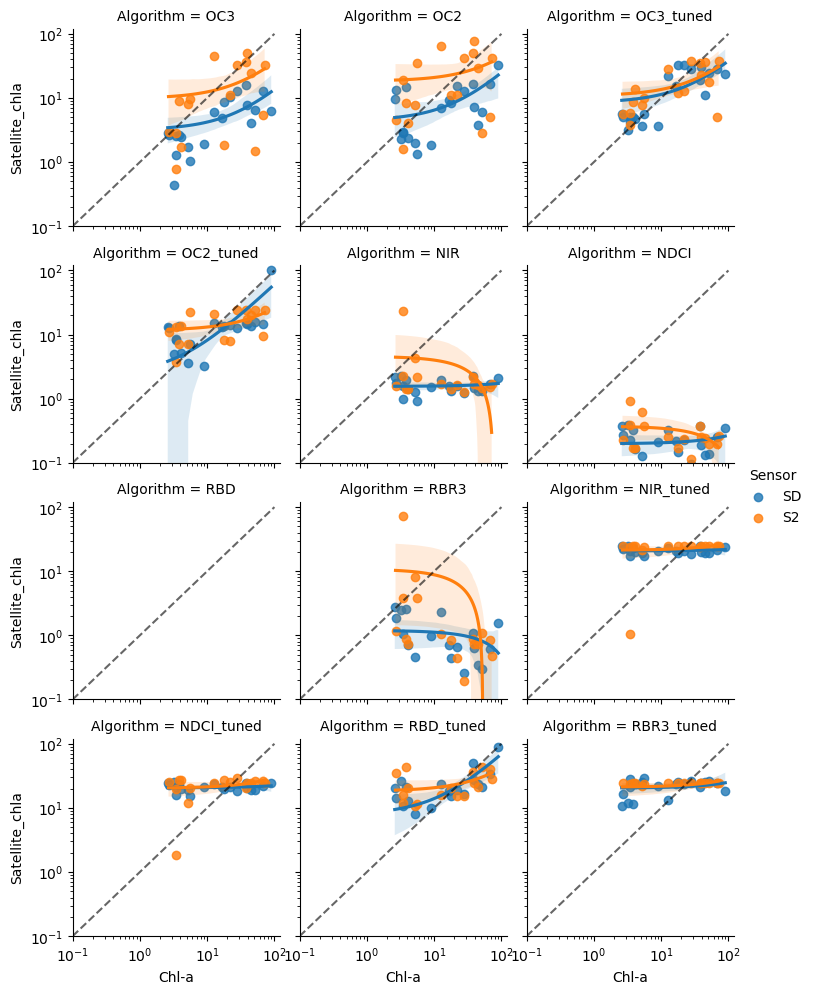

In [428]:
def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
#     res = sp.stats.linregress(data.dropna()[x]**order, data.dropna()[y])
#     mae = MAE(data.dropna()[x], data.dropna()[y])
#     mape = MAPE(data.dropna()[x], data.dropna()[y])
#     rmsd = RMSD(data.dropna()[x], data.dropna()[y])
#     bias = SSPB(data.dropna()[x], data.dropna()[y])
#     mad = MAD(data.dropna()[x], data.dropna()[y])
#     mapd = MAPD(data.dropna()[x], data.dropna()[y])
#     ax = plt.gca()
#     ax.text(0.1, 0.77, '$R^2$ = {:.2f} \np = {:.2g}\
#                        \nRMSD = {:.2f} \nMAPD = {:.2f}%\
#                        \nMAD = {:.2f} \nBias = {:.2f}%'.format(res.rvalue**2,
#                                                               res.pvalue,
#                                                               rmsd, mapd,
#                                                               mad, bias),
#             transform=ax.transAxes)

    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)

g = sns.lmplot(data=insit_melt[insit_melt.date_diff <= '3 days'],
               x='Chl-a', y='Satellite_chla', col='Algorithm', hue='Sensor',
               col_wrap=3,
               facet_kws={'sharey':True, 'sharex':True}, height=2.5)
# g = sns.relplot(data=insit_melt[insit_melt.date_diff <= '3 days'],
#                 x='Chl-a', y='Satellite_chla', col='Algorithm', hue='Sensor',
#                col_wrap=3, kind='scatter',
#                facet_kws={'sharey':True, 'sharex':True}, height=2.3)
# g.map_dataframe(annotate, y='Satellite_chla', plot=True)# lims=[0.1, 100])

# lims=[[0.1, 100], [0.1, 100], [0.1, 100],
#       [.1, 100], [.1, 100], [.1, 100],
#       [0.1, 100], [0.1, 100]]

for ax in g.axes:
    ax.set_xlim(1e-1, 1.2e2)
    ax.set_ylim(1e-1, 1.2e2)
    ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)
    ax.set_yscale('log')
    ax.set_xscale('log')
    
plt.show()

## Need to work out how to do the plotting in a nice way!

- think I should divide into a few seperate groups

I have:

OC2, OC3, NIR, NDCI, RBD, RBR3
(6 algorithms)

S2, SD
(2 sensors)

tuned/not tuned (2 tuning options)

BUT actually most algorithms are meaningless without coefficient

only OC2 and OC3 have generalised coeffs




In [445]:
not_tuned = insit_melt.Algorithm.isin(['NIR', 'NDCI', 'RBD', 'RBR3'])

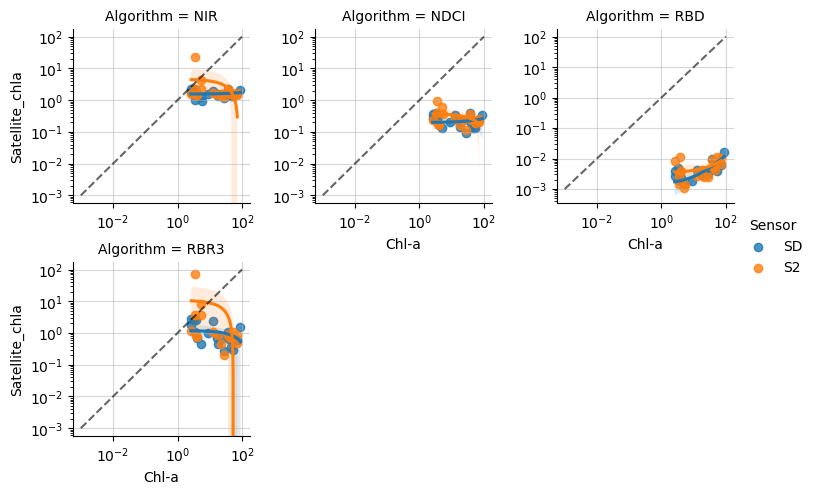

In [446]:

g = sns.lmplot(data=insit_melt[(insit_melt.date_diff <= '3 days')& not_tuned],
               x='Chl-a', y='Satellite_chla', col='Algorithm', hue='Sensor',
               col_wrap=3,
               facet_kws={'sharey':False, 'sharex':False}, height=2.5)

for ax in g.axes:
#     ax.set_xlim(1e-3, 1.2e2)
#     ax.set_ylim(1e-3, 1.2e2)
    ax.plot([1e-3, 100], [1e-3, 100], 'k--', alpha=0.6)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.grid(alpha=0.5)
    
plt.show()

In [484]:
def p_sig(p_val):
    if p_val >= 0.05:
        return '(ns)'
    elif p_val >= 0.01:
        return '*'
    elif p_val >= 0.001:
        return '**'
    else:
        return '***'

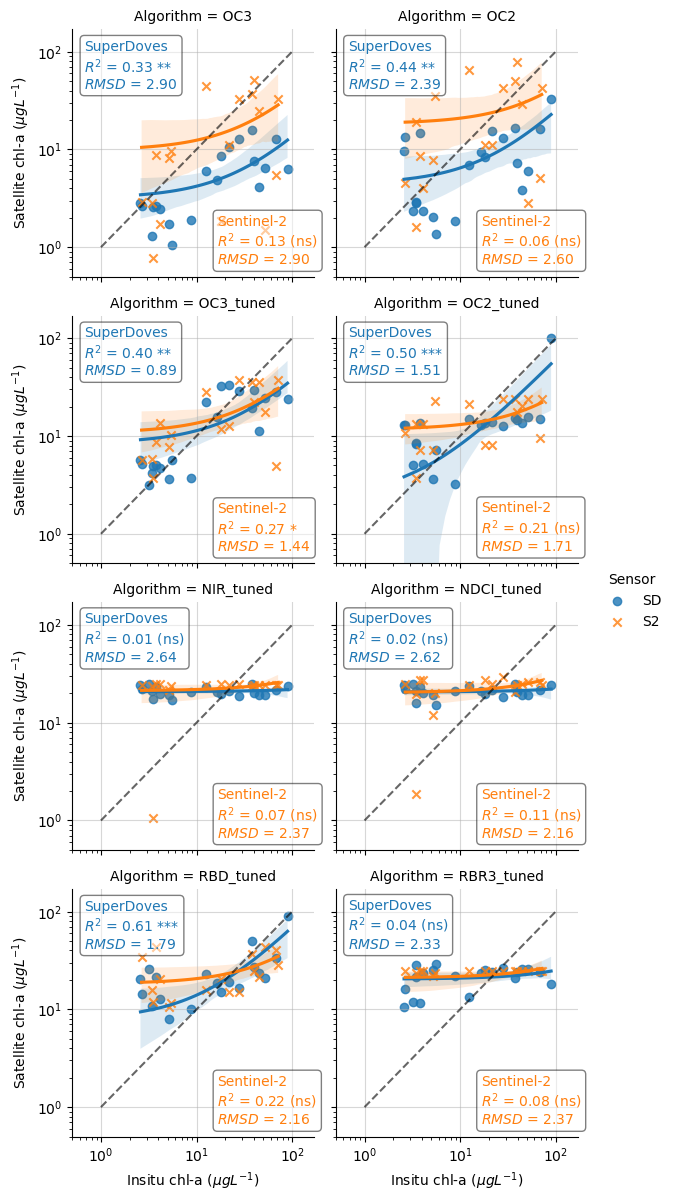

In [508]:
def annotate(data, x='Chl-a', y='sdfkjdf', order=1, plot=True, lims=None, **kws):
    res = sp.stats.linregress(data.dropna()[x]**order, data.dropna()[y])
    mae = MAE(data.dropna()[x], data.dropna()[y])
    mape = MAPE(data.dropna()[x], data.dropna()[y])
    rmsd = RMSD(data.dropna()[x], data.dropna()[y])
    bias = SSPB(data.dropna()[x], data.dropna()[y])
    mad = MAD(data.dropna()[x], data.dropna()[y])
    mapd = MAPD(data.dropna()[x], data.dropna()[y])
    
    psig = p_sig(res.pvalue)
    
    ax = plt.gca()
    if data.Sensor.values[0] == 'SD':
        textstr = '\n'.join((
                             r'SuperDoves',
                             r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                         psig),
                             r'$RMSD$ = {:.2f}'.format(rmsd, )))
        ax.text(0.05, 0.76, textstr,
            transform=ax.transAxes, bbox=dict(boxstyle='round',
                                              facecolor='white',
                                              alpha=0.5), color=sns.color_palette()[0])
    if data.Sensor.values[0] == 'S2':
        textstr = '\n'.join((
                             r'Sentinel-2',
                             r'$R^2$ = {:.2f} {}'.format(res.rvalue**2,
                                                         psig),
                             r'$RMSD$ = {:.2f}'.format(rmsd, )))
        ax.text(0.6, 0.05, textstr,
            transform=ax.transAxes, bbox=dict(boxstyle='round',
                                              facecolor='white',
                                              alpha=0.5), color=sns.color_palette()[1])

    if plot:
        ax.plot([0.1, 100], [0.1, 100], 'k--', alpha=0.6)

g = sns.lmplot(data=insit_melt[(insit_melt.date_diff <= '3 days')& ~not_tuned],
               x='Chl-a', y='Satellite_chla', col='Algorithm', hue='Sensor',
               col_wrap=2, markers=['o', 'x'],
               facet_kws={'sharey':True, 'sharex':True}, height=3.)

g.map_dataframe(annotate, y='Satellite_chla', plot=False)# lims=[0.1, 100])

for ax in g.axes:
    ax.set_xlim(.5e0, 1.7e2)
    ax.set_ylim(.5e0, 1.7e2)
    ax.plot([1e0, 100], [1e0, 100], 'k--', alpha=0.6)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.grid(alpha=0.5)
    ax.set_xlabel('Insitu chl-a ($\mu g L^{-1}$)')
    ax.set_ylabel('Satellite chl-a ($\mu g L^{-1}$)')
    
plt.show()

In [507]:
sns.color_palette()[1]

(1.0, 0.4980392156862745, 0.054901960784313725)